<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/tensorflow_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def load_and_prepare_data(test_size: float = 0.2, val_size: float = 0.2, seed: int = 42):
    """
    Load California Housing, split into train/val/test, scale features using StandardScaler.

    Args:
        test_size: Fraction for test split (from full data).
        val_size: Fraction for validation split (from train portion).
        seed: Random seed.

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test as np.float32 arrays.
    """
    data = fetch_california_housing()
    X = data.data
    y = data.target.reshape(-1, 1)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        y_train.astype(np.float32),
        X_val.astype(np.float32),
        y_val.astype(np.float32),
        X_test.astype(np.float32),
        y_test.astype(np.float32),
    )


X_train, y_train, X_val, y_val, X_test, y_test = load_and_prepare_data()
input_size = X_train.shape[1]

Epoch 10/200  Train MSE: 0.3671  Val MSE: 0.3984
Epoch 20/200  Train MSE: 0.3102  Val MSE: 0.3360
Epoch 30/200  Train MSE: 0.2900  Val MSE: 0.3125
Epoch 40/200  Train MSE: 0.2784  Val MSE: 0.3131
Epoch 50/200  Train MSE: 0.2688  Val MSE: 0.2993
Epoch 60/200  Train MSE: 0.2652  Val MSE: 0.2995
Epoch 70/200  Train MSE: 0.2577  Val MSE: 0.2908
Epoch 80/200  Train MSE: 0.2530  Val MSE: 0.2827
Epoch 90/200  Train MSE: 0.2475  Val MSE: 0.2962
Epoch 100/200  Train MSE: 0.2428  Val MSE: 0.2812
Epoch 110/200  Train MSE: 0.2379  Val MSE: 0.2799
Epoch 120/200  Train MSE: 0.2352  Val MSE: 0.2922
Epoch 130/200  Train MSE: 0.2289  Val MSE: 0.2838
Epoch 140/200  Train MSE: 0.2272  Val MSE: 0.2819
Epoch 150/200  Train MSE: 0.2222  Val MSE: 0.2790
Epoch 160/200  Train MSE: 0.2193  Val MSE: 0.2763
Epoch 170/200  Train MSE: 0.2149  Val MSE: 0.2741
Epoch 180/200  Train MSE: 0.2139  Val MSE: 0.2709
Epoch 190/200  Train MSE: 0.2118  Val MSE: 0.2702
Epoch 200/200  Train MSE: 0.2083  Val MSE: 0.2652
Test MSE:

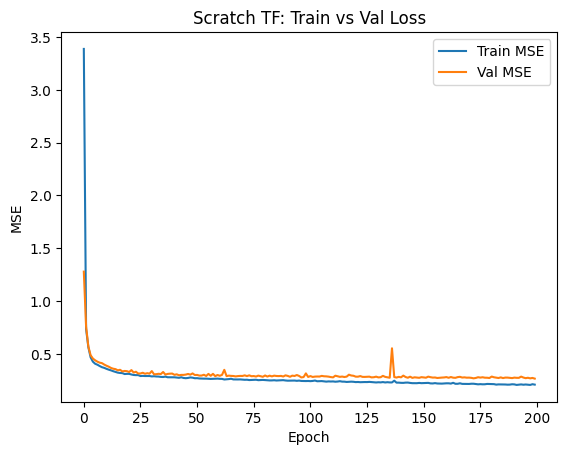

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


def relu(x: tf.Tensor) -> tf.Tensor:
    """
    ReLU activation.

    Args:
        x: Input tensor.
    Returns:
        ReLU(x).
    """
    return tf.maximum(x, 0.0)


def init_layer(in_dim: int, out_dim: int, seed: int = 42):
    """
    Initialize weights and bias for a dense layer.

    Args:
        in_dim: Input dimension.
        out_dim: Output dimension.
        seed: Random seed for reproducibility.

    Returns:
        (W, b) as tf.Variable tensors.
    """
    tf.random.set_seed(seed)
    W = tf.Variable(tf.random.normal([in_dim, out_dim], stddev=0.05), trainable=True)
    b = tf.Variable(tf.zeros([out_dim]), trainable=True)
    return W, b


# Params (3 hidden layers + output)
W1, b1 = init_layer(input_size, 64, seed=1)
W2, b2 = init_layer(64, 64, seed=2)
W3, b3 = init_layer(64, 64, seed=3)
W4, b4 = init_layer(64, 1, seed=4)

params = [W1, b1, W2, b2, W3, b3, W4, b4]

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

batch_size = 256
epochs = 200

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10_000).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

train_losses, val_losses = [], []


def forward(x: tf.Tensor) -> tf.Tensor:
    """
    Forward pass using manual dense layers.

    Args:
        x: Input tensor shape (batch, input_size).
    Returns:
        Output predictions shape (batch, 1).
    """
    x = relu(tf.matmul(x, W1) + b1)
    x = relu(tf.matmul(x, W2) + b2)
    x = relu(tf.matmul(x, W3) + b3)
    x = tf.matmul(x, W4) + b4
    return x


for epoch in range(1, epochs + 1):
    # Train
    epoch_train_loss = tf.keras.metrics.Mean()
    for xb, yb in train_ds:
        with tf.GradientTape() as tape:
            preds = forward(xb)
            loss = tf.reduce_mean(tf.square(preds - yb))  # MSE
        grads = tape.gradient(loss, params)
        optimizer.apply_gradients(zip(grads, params))
        epoch_train_loss.update_state(loss)

    # Val
    epoch_val_loss = tf.keras.metrics.Mean()
    for xb, yb in val_ds:
        preds = forward(xb)
        loss = tf.reduce_mean(tf.square(preds - yb))
        epoch_val_loss.update_state(loss)

    tr = float(epoch_train_loss.result().numpy())
    va = float(epoch_val_loss.result().numpy())
    train_losses.append(tr)
    val_losses.append(va)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}  Train MSE: {tr:.4f}  Val MSE: {va:.4f}")

# Test
test_preds = forward(tf.convert_to_tensor(X_test))
test_mse = float(tf.reduce_mean(tf.square(test_preds - y_test)).numpy())
print("Test MSE:", test_mse)

plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.title("Scratch TF: Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()